Title: demand_prep.ipynb

Purpose: Script to prepare demand data

Author: Onno Nennecke on 04.03.2025 Modified: 18.06.2025

Input data: 

- demand_fit_values
    - This file lies here: /climca/people/onennecke/population_data/vdW_data/
- population_t2m_grid
    - This file lies here: /climca/people/onennecke/population_data/vdW_data/

Output data:

- demand_fit_values_week
    - This file lies here: /climca/people/onennecke/population_data/
- population_regrid
    - This file lies here: /climca/people/onennecke/population_data/
- population_regrid_weights
    - This file lies here: /climca/people/onennecke/population_data/


#### Load packages

In [ ]:
import xarray as xr
import numpy as np
# Load cdo package for regridding
from cdo import Cdo
cdo = Cdo()
# Plot the population data
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import Functions.grid_func as grid_func

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


##### Load population data from vdW Paper

In [2]:
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/vdW_data/demand_fit_values.nc') #('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/demand_fit_values.nc')
demand_population_t2m_grid = xr.open_dataset('/climca/people/onennecke/population_data/vdW_data/population_t2m_grid.nc') #('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid.nc')
# demand_population_t2m_grid_weights = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid_weights.nc')

##### Create new fit values for the whole week

In [3]:
v_weekday = demand_fit_values.sel(period = 'weekday')
v_weekend = demand_fit_values.sel(period = 'weekend')
v_week = v_weekday * 5/7 + v_weekend * 2/7
v_week.coords['period'] = 'week'
# v_week

In [6]:
demand_fit_values_week = xr.concat([demand_fit_values, v_week.expand_dims('period')], dim='period')
# demand_fit_values_week.sel(country = 9, period = 'week')

# Save new demand fit values
demand_fit_values_week.to_netcdf('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

##### Regrid data

In [5]:
# Define a rough area for Germany
n = 55
s = 47
w = 6
e = 15

In [6]:
demand_population_t2m_grid_de = demand_population_t2m_grid.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']
# demand_population_t2m_grid_weights_de = demand_population_t2m_grid_weights.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']

In [ ]:
new_grid = grid = grid_func.create_ref_grid('population', s = 47, n = 57, w = 5, e = 17)
# Convert the DataArray to a Dataset
new_grid_ds = new_grid.to_dataset(name='population')
new_grid_ds
# Save grid as raster file
new_grid_ds.to_netcdf('/climca/people/onennecke/population_data/population_template.nc')
'''
For cdo.remapsum() I had to fix the offshore grid with these commands (because the attributes (especially gridtype)
are not saved correctly otherwise:
cdo setgrid,grid.txt population_template.nc population_template_fixed.nc
grid.txt is in the same folder
'''

In [ ]:
population_grid_CIESIN = '/climca/people/onennecke/population_data/vdW_data/population_t2m_grid.nc'
# Determine directory for regridding
population_regrid_CIESIN = '/climca/people/onennecke/population_data/population_regrid.nc'

# Take the data from population_t2m_grid and regrid it to the same grid as the capacity data (and save it to population_regrid.nc)
cdo.remapsum(
    '/climca/people/onennecke/population_data/population_template_fixed.nc',
    input=population_grid_CIESIN,
    output=population_regrid_CIESIN,
    readCdf=True,
    options="-f nc",
)


'/climca/people/onennecke/population_data/population_regrid.nc'

In [ ]:
# Load the regridded population data
population_regrid_CIESIN = xr.open_dataset(population_regrid_CIESIN)
# population_regrid_CIESIN

In [ ]:
# Select the population data for Germany (country code 9) and slice it
population_regrid_CIESIN_slice = population_regrid_CIESIN.sel(country=9)['population']
new_regrid = population_regrid_CIESIN_slice.isel(lon=slice(1, -1), lat=slice(0, -1))

# Save the sliced regridded population data
new_regrid.to_netcdf('/climca/people/onennecke/population_data/population_regrid.nc', mode='w')
# new_regrid


<xarray.DataArray 'population' (lat: 9, lon: 10)> Size: 720B
[90 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 80B 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0
  * lat      (lat) float64 72B 47.0 48.0 49.0 50.0 51.0 52.0 53.0 54.0 55.0
    country  float64 8B 9.0
Attributes:
    standard_name:  region mask
    long_name:      Boolean mask for selected region(s)
    units:          [-]

In [37]:
population_germany = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid.nc')
population_germany

<xarray.Dataset> Size: 880B
Dimensions:     (lon: 10, lat: 9)
Coordinates:
  * lon         (lon) float64 80B 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0
  * lat         (lat) float64 72B 47.0 48.0 49.0 50.0 51.0 52.0 53.0 54.0 55.0
    country     float64 8B ...
Data variables:
    population  (lat, lon) float64 720B ...

In [40]:
population_germany['population']
print(np.nansum(population_germany['population'].values) / 1000000)
# print(np.nansum(population_regrid_ISIMIP_slice.values) / 1000000)

78.18941650702027


#### Calculate weights

In [47]:
population_germany_weights = population_germany['population'] / np.nansum(population_germany['population'].values)
# Save weights
population_germany_weights.to_netcdf('/climca/people/onennecke/population_data/population_regrid_weights.nc', mode='w')
# population_regrid_ISIMIP_slice_weights = population_regrid_ISIMIP_slice / np.nansum(population_regrid_ISIMIP_slice.values)

#### Plot population data

In [ ]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

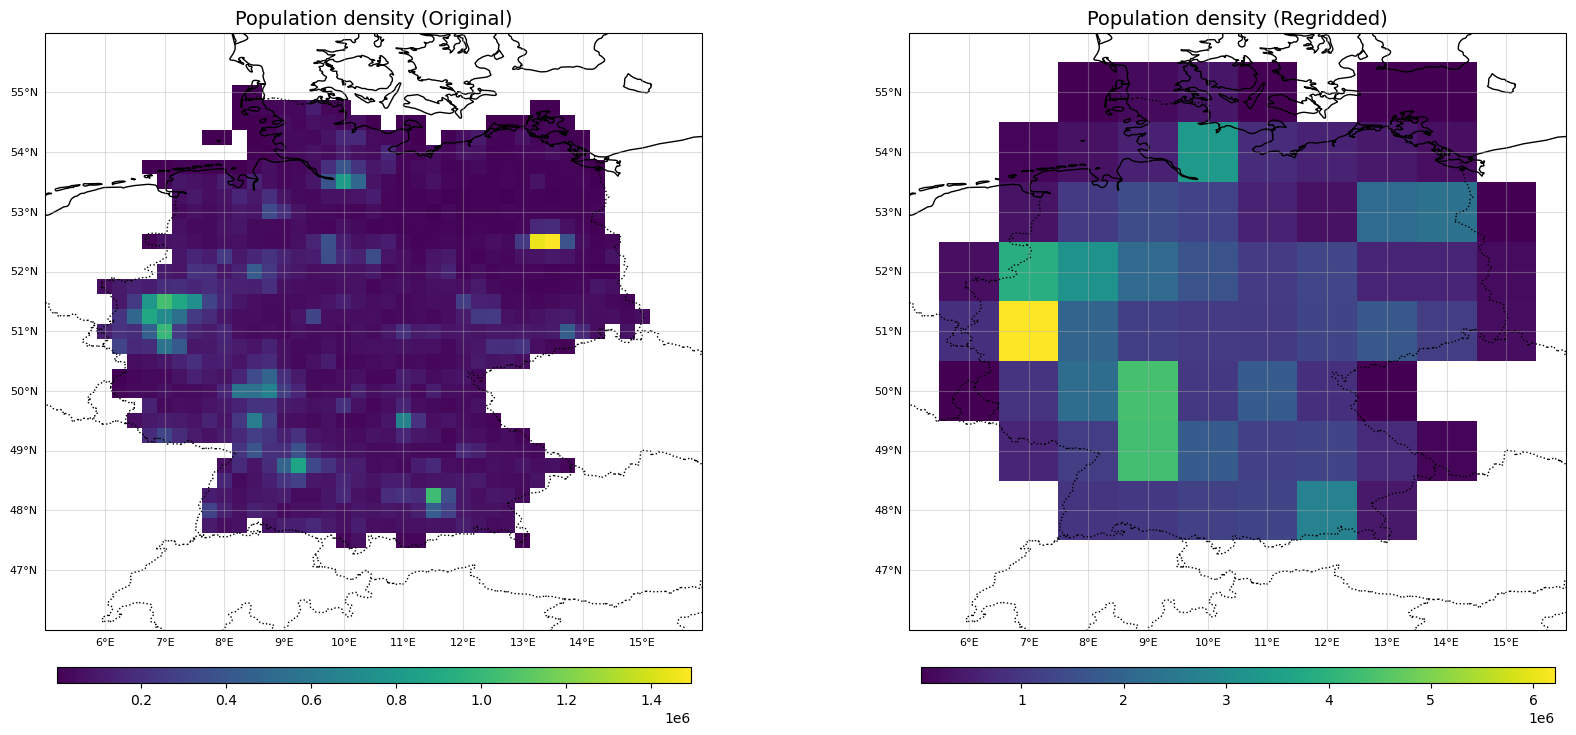

In [49]:
# Edges for each dataset
lon_edges1 = demand_population_t2m_grid_de['lon'].values
lat_edges1 = demand_population_t2m_grid_de['lat'].values

lon_edges2 = new_regrid['lon'].values
lat_edges2 = new_regrid['lat'].values

# Create side-by-side subplots
fig, axes = plt.subplots(ncols=2, figsize=(18, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# First plot
ax1 = axes[0]
ax1.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax1.set_title('Population density (Original)', fontsize=14)

im1 = ax1.pcolormesh(lon_edges1, lat_edges1, demand_population_t2m_grid_de, transform=ccrs.PlateCarree(), cmap='viridis')
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=40)

# Second plot
ax2 = axes[1]
ax2.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree())
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax2.set_title('Population density (Regridded)', fontsize=14)

im2 = ax2.pcolormesh(lon_edges2, lat_edges2, new_regrid, transform=ccrs.PlateCarree(), cmap='viridis')
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=40)

plt.tight_layout()
plt.show()
